# **Implementación del Algoritmo de Shor para resolver el DLP**

## Conjetura sobre los primos seguros

### Rodrigo Hernández Sacristán

#### Máster en Computación Cuántica, Universidad Internacional de la Rioja (UNIR)

In [2]:
## LIBRERÍAS NECESARIAS 

import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate 
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram
from IPython.display import display
from qiskit.quantum_info import Operator
from qiskit.circuit.library import QFT
import warnings
import random
from collections import Counter
import sys

## FUNCIONES EXTERNAS

In [ ]:
def es_generador(g, p):
    """Verifica si g es generador de Z_p^*"""
    orden = p - 1
    elementos_vistos = set()
    for k in range(1, orden + 1):
        elementos_vistos.add(pow(g, k, p))
    return len(elementos_vistos) == orden

def residuo_centrado(z, q):
    r = z % q
    if r > q // 2:
        r -= q
    return r

def extraer_modulo_coprimo(c_prima, mod_total):
    """ Extrae el mayor divisor 'm' de mod_total tal que gcd(c_prima, m) == 1 """
    m = mod_total
    while True:
        g = math.gcd(c_prima, m)
        if g == 1:
            break
        m = m // g
    return m

def combinar_teorema_chino(X, M, a, m):
    """ Combina x ≡ X (mod M) y x ≡ a (mod m) usando el Teorema Chino del Resto """
    g = math.gcd(M, m)
    if (a - X) % g != 0:
        return None, None  # Inconsistencia por ruido de fase
    
    m_red = m // g
    M_red = M // g
    inv = pow(M_red, -1, m_red)
    diff = (a - X) // g
    k = (diff * inv) % m_red
    
    M_nuevo = (M * m) // g
    X_nuevo = (X + k * M) % M_nuevo
    return X_nuevo, M_nuevo

def posprocesamiento_shor(resultados, g, h, p, q, top_n):
    p_sub_1 = p - 1  # 22
    total_shots = sum(resultados.values())
    
    # Ordenamos los estados de mayor a menor frecuencia
    resultados_ordenados = sorted(resultados.items(), key=lambda item: item[1], reverse=True)
    
    print("=" * 80)
    print("ANÁLISIS DIDÁCTICO DE LOS ESTADOS MEDIDOS EN EL HISTOGRAMA")
    print("=" * 80)
    print(f"Ecuación a resolver: {g}^x ≡ {h} (mod {p}) ")
    print("=" * 80 + "\n")
    
    # Analizamos los top_n estados más frecuentes
    for estado, freq in resultados_ordenados[:top_n]:
        d_str, c_str = estado.split(' ')
        c = int(c_str, 2)
        d = int(d_str, 2)
        
        
        c_prima = int((c * p_sub_1 - residuo_centrado(c * p_sub_1, q)) / q) % p_sub_1
        d_prima = round(d * p_sub_1 / q) % p_sub_1
        
        pct = (freq / total_shots) * 100
        
        print(f"Estado medido: |d = {d:2d}, c = {c:2d}⟩ (Proyección: M = {d_prima:2d}, c' = {c_prima:2d})  -->  Frecuencia: {freq:4d} veces ({pct:5.1f}%)")
        
        gcd_val = math.gcd(c_prima, p_sub_1)
        
        if gcd_val == 1:
            c_inv = pow(c_prima, -1, p_sub_1)
            x_cand = (-d_prima * c_inv) % p_sub_1
            val_mod = pow(g, x_cand, p)
            
            print(f"  ├── ¿c' es invertible mod {p_sub_1}?: SÍ (Inverso: c'^-1 ≡ {c_inv} mod {p_sub_1})")
            print(f"  ├── Fórmula: x = -M * c'^-1  -->  x = -{d_prima} * {c_inv} ≡ {x_cand} mod {p_sub_1}")
            
            if val_mod == h:
                print(f"  └── ¡ÉXITO! Verificación: {g}^{x_cand} ≡ {h} mod {p} (¡Da {val_mod}!)")
            else:
                print(f"  └── DESCARTADO: Verificación {g}^{x_cand} ≡ {val_mod} ≠ {h} mod {p} (Ruido de fase)")
        else:
            print(f"  ├── ¿c' es invertible mod {p_sub_1}?: NO (gcd({c_prima}, {p_sub_1}) = {gcd_val} > 1)")
            print(f"  └── CÓMPUTO IMPOSIBLE: No existe inverso de {c_prima} modulo {p_sub_1}. Este disparo no sirve.")
        
        print("-" * 80)

## ORÁCULO BASADO EN MATRICES $O(4^{l})$

In [5]:
def aplicar_oraculo_matrices(g, h, p, qc, reg_A, reg_B, reg_C, reg_anc=None):
    '''
    Implementa el oráculo cuántico para f(a,b) = g^a * h^(-b) mod p usando matrices de permutación
    '''
    
    num_qubits_reg = len(reg_A)
    q= 2**num_qubits_reg  # si  l=5 cúbits pues q=32
    
    # ----------------------------------------------------------------------
    # PASO 1: Inicializar el Registro C en |1> (ya que empezamos multiplicando)
    # ----------------------------------------------------------------------
    # El registro C por defecto está en |00000>, aplicamos una puerta X (NOT)
    # en el primer cúbit para obtener el estado clásico |1> (00001 en binario)
    qc.x(reg_C[0])
    
    # ----------------------------------------------------------------------
    # PASO 2: Calcular las potencias clásicas de las bases mod p
    # ----------------------------------------------------------------------
    # Registro A:
    factores_A = [pow(g, 2**i, p) for i in range(num_qubits_reg)]
    
    # Registro B: potencias del inverso de h. 
    h_inv = pow(h, -1, p)
    factores_B = [pow(h_inv, 2**j, p) for j in range(num_qubits_reg)]
    

    # -------------------------------------------------------------------------------------------------
    # PASO 3: Función interna para crear la matriz de multiplicación modular
    # -------------------------------------------------------------------------------------------------
    def crear_matriz_multiplicacion(k): 
        matriz = np.zeros((q, q)) # Matriz qxq rellena de 0s
        
        for x in range(q):
            if x < p: # Para estados válidos dentro de Z_p^*
                if x == 0:
                    estado_destino = 0
                else:
                    estado_destino = (x * k) % p
            else: 
                # Para  los estados que están fuera del grupo, los mapeamos a sí mismos
                # para mantener la matriz unitaria (identidad en la esquina inferior derecha)
                estado_destino = x
                
            matriz[estado_destino, x] = 1 # Matriz de permutación unitaria
            
        return UnitaryGate(matriz, label=f"x*{k} mod {p}")

    # ----------------------------------------------------------------------
    # PASO 4: Aplicar multiplicaciones controladas por el Registro A
    # ----------------------------------------------------------------------
    for i in range(num_qubits_reg):
        potencia = factores_A[i]
        
        # Optimización: si multiplicar por 1 no cambia el estado, nos saltamos la puerta
        if potencia == 1:
            continue
            
        puerta_mult = crear_matriz_multiplicacion(potencia)
        puerta_controlada = puerta_mult.control(1)
        
        # El cúbit de control es reg_A[i], y actúa sobre todo el reg_C
        qc.append(puerta_controlada, [reg_A[i]] + list(reg_C)) 
        
    # ----------------------------------------------------------------------
    # PASO 5: Aplicar multiplicaciones controladas por el Registro B
    # ----------------------------------------------------------------------
    for j in range(num_qubits_reg):
        potencia = factores_B[j]
        
        if potencia == 1:
            continue
            
        puerta_mult = crear_matriz_multiplicacion(potencia)
        puerta_controlada = puerta_mult.control(1)
        
        # El cúbit de control es reg_B[j], y actúa sobre todo el reg_C
        qc.append(puerta_controlada, [reg_B[j]] + list(reg_C))

# PRIMOS NO SEGUROS

## El objetivo es calcular $x$ tal que $3^x=20\pmod{31}$. 

3 es generador de Z_31^*. Continuando con el resto del circuito...
[Simulador] Lanzando 10000 disparos...
ANÁLISIS DIDÁCTICO DE LOS ESTADOS MEDIDOS EN EL HISTOGRAMA
Ecuación a resolver: 3^x ≡ 20 (mod 31) 

Estado medido: |d =  0, c =  0⟩ (Proyección: M =  0, c' =  0)  -->  Frecuencia:  337 veces (  3.4%)
  ├── ¿c' es invertible mod 30?: NO (gcd(0, 30) = 30 > 1)
  └── CÓMPUTO IMPOSIBLE: No existe inverso de 0 modulo 30. Este disparo no sirve.
--------------------------------------------------------------------------------
Estado medido: |d =  0, c = 16⟩ (Proyección: M =  0, c' = 15)  -->  Frecuencia:  334 veces (  3.3%)
  ├── ¿c' es invertible mod 30?: NO (gcd(15, 30) = 15 > 1)
  └── CÓMPUTO IMPOSIBLE: No existe inverso de 15 modulo 30. Este disparo no sirve.
--------------------------------------------------------------------------------
Estado medido: |d = 15, c =  2⟩ (Proyección: M = 14, c' =  2)  -->  Frecuencia:  317 veces (  3.2%)
  ├── ¿c' es invertible mod 30?: NO (gcd(2, 30) = 

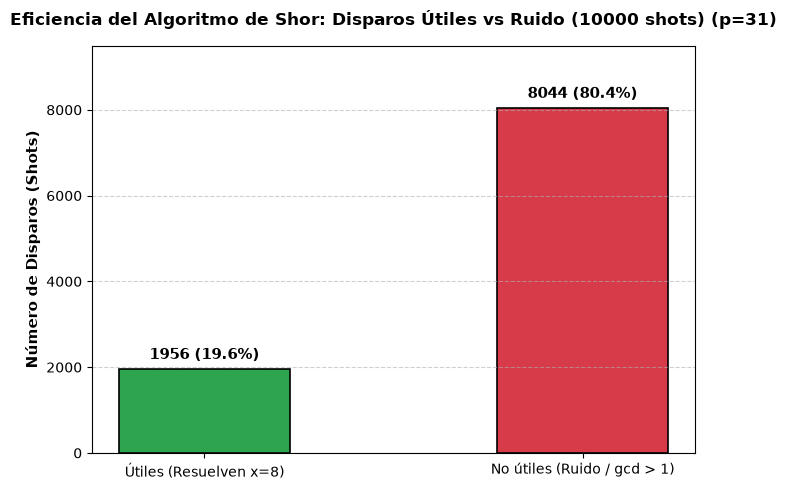

In [10]:
# 1. Definimos los parámetros

g=3
h=20
p=31 #Es obligatorio el p=23
q=32
l=5

if es_generador(g,p):
    print(f"{g} es generador de Z_{p}^*. Continuando con el resto del circuito...")

# 2. Definimos los registros cuánticos y clásicos
    reg_A = QuantumRegister(l, 'A')
    reg_B = QuantumRegister(l, 'B')
    reg_C = QuantumRegister(l, 'C')

    clreg_A = ClassicalRegister(l, 'medida_c')
    clreg_B = ClassicalRegister(l, 'medida_d')

# 3. Creamos el circuito
    qc=QuantumCircuit(reg_A,reg_B,reg_C,clreg_A,clreg_B)

# 4. Aplicamos puertas Hadamard en los registros A y B
    qc.h(reg_A)
    qc.h(reg_B)
    qc.barrier()

# 5. Aplicamos el oráculo
    aplicar_oraculo_matrices(g, h, p, qc, reg_A, reg_B, reg_C)
    qc.barrier()

# 6. Aplicamos ahora la QFT en los dos primeros registros
    qc.append(QFTGate(num_qubits=l), reg_A)
    qc.append(QFTGate(num_qubits=l), reg_B)
    qc.barrier()

# 7. Procedemos a la medición
    qc.measure(reg_A, clreg_A)
    qc.measure(reg_B, clreg_B)

# 8. Pintamos el circuito completo
    # Dibujamos el circuito usando el motor de Matplotlib ('mpl')
    # Usamos el estilo 'iqp', que es el estándar moderno de IBM
    fig = qc.draw('mpl', style='iqp')

    # Guardamos el dibujo directamente en un archivo png
    fig.savefig('circuito_shor(23).png', bbox_inches='tight',dpi=300)

# 9. Pasamos ya a la simulación 
    num_disparos = 10000  
    print(f"[Simulador] Lanzando {num_disparos} disparos...")

    simulador = AerSimulator()
    qc_est_transpilado = transpile(qc, backend=simulador)

    job = simulador.run(qc_est_transpilado, shots=num_disparos)
    resultados = job.result().get_counts()

    posprocesamiento_shor(resultados, g, h, p, q, 35)

# ==============================================================================
# 11. VISUALIZACIÓN DE HISTOGRAMAS (DECIMAL Y BALANCE ÉXITO/RUIDO)
# ==============================================================================

# 1. Decodificación a formato decimal |d=X,c=Y> y clasificación de utilidad
    resultados_decimal = {}
    conteo_utiles = 0
    conteo_no_utiles = 0

    p_sub_1 = p - 1  # 22
    total_shots = sum(resultados.values())

    for estado_bin, freq in resultados.items():
        d_str, c_str = estado_bin.split(' ')
        c = int(c_str, 2)
        d = int(d_str, 2)
        
        # Formato decimal idéntico a la captura
        label_decimal = f"|d={d},c={c}>"
        resultados_decimal[label_decimal] = freq
        
        # Verificación de utilidad matemática
        c_prima = int((c * p_sub_1 - residuo_centrado(c * p_sub_1, q)) / q) % p_sub_1
        d_prima = round(d * p_sub_1 / q) % p_sub_1
        
        es_util = False
        if math.gcd(c_prima, p_sub_1) == 1:
            c_inv = pow(c_prima, -1, p_sub_1)
            x_cand = (-d_prima * c_inv) % p_sub_1
            if pow(g, x_cand, p) == h:
                es_util = True
                
        if es_util:
            conteo_utiles += freq
        else:
            conteo_no_utiles += freq

    # ------------------------------------------------------------------------------
    # HISTOGRAMA: Balance de Disparos Útiles vs No Útiles
    # ------------------------------------------------------------------------------
    fig2, ax = plt.subplots(figsize=(7, 5))

    categorias = ['Útiles (Resuelven x=8)', 'No útiles (Ruido / gcd > 1)']
    valores = [conteo_utiles, conteo_no_utiles]
    colores = ['#2ea44f', '#d73a49']  # Verde para éxito, Rojo para ruido

    bars = ax.bar(categorias, valores, color=colores, width=0.45, edgecolor='black', linewidth=1.2)

    # Añadir los conteos absolutos y porcentajes encima de cada barra
    for bar in bars:
        yval = bar.get_height()
        porcentaje = (yval / total_shots) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, 
            yval + (total_shots * 0.015), 
            f"{yval} ({porcentaje:.1f}%)", 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            fontweight='bold'
        )

    ax.set_ylabel('Número de Disparos (Shots)', fontsize=11, fontweight='bold')
    ax.set_title(f'Eficiencia del Algoritmo de Shor: Disparos Útiles vs Ruido ({total_shots} shots) (p={p})', fontsize=12, fontweight='bold', pad=15)
    ax.set_ylim(0, max(valores) * 1.18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    fig2.savefig('histograma_shor_utilidad(31)_matrices.png', dpi=300)
    print(f"\n=== HISTOGRAMA 2: CLASIFICACIÓN DE UTILIDAD (p={p})===")
    display(fig2)
    plt.close(fig2)


else:
    print(f"{g} NO es generador de Z_{p}^*. Abortando el programa.")
    exit()  # Termina la ejecución del programa

## El objetivo es calcular $x$ tal que $2^x=29\pmod{61}$. 

2 es generador de Z_61^*. Continuando con el resto del circuito...
[Simulador] Lanzando 10000 disparos...
ANÁLISIS DIDÁCTICO DE LOS ESTADOS MEDIDOS EN EL HISTOGRAMA
Ecuación a resolver: 2^x ≡ 29 (mod 61) 

Estado medido: |d = 48, c = 48⟩ (Proyección: M = 45, c' = 45)  -->  Frecuencia:  180 veces (  1.8%)
  ├── ¿c' es invertible mod 60?: NO (gcd(45, 60) = 15 > 1)
  └── CÓMPUTO IMPOSIBLE: No existe inverso de 45 modulo 60. Este disparo no sirve.
--------------------------------------------------------------------------------
Estado medido: |d = 32, c = 32⟩ (Proyección: M = 30, c' = 30)  -->  Frecuencia:  165 veces (  1.7%)
  ├── ¿c' es invertible mod 60?: NO (gcd(30, 60) = 30 > 1)
  └── CÓMPUTO IMPOSIBLE: No existe inverso de 30 modulo 60. Este disparo no sirve.
--------------------------------------------------------------------------------
Estado medido: |d =  0, c =  0⟩ (Proyección: M =  0, c' =  0)  -->  Frecuencia:  160 veces (  1.6%)
  ├── ¿c' es invertible mod 60?: NO (gcd(0, 60) 

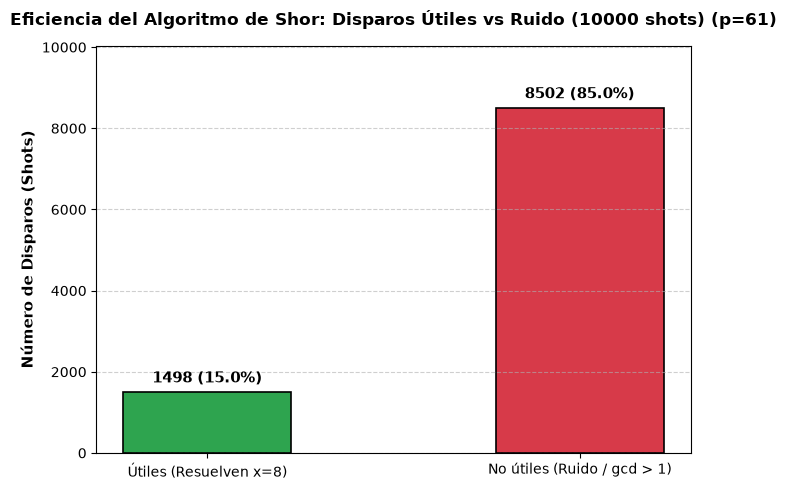

In [16]:
# 1. Definimos los parámetros

g=2
h=29
p=61 
q=64
l=6

if es_generador(g,p):
    print(f"{g} es generador de Z_{p}^*. Continuando con el resto del circuito...")

# 2. Definimos los registros cuánticos y clásicos
    reg_A = QuantumRegister(l, 'A')
    reg_B = QuantumRegister(l, 'B')
    reg_C = QuantumRegister(l, 'C')

    clreg_A = ClassicalRegister(l, 'medida_c')
    clreg_B = ClassicalRegister(l, 'medida_d')

# 3. Creamos el circuito
    qc=QuantumCircuit(reg_A,reg_B,reg_C,clreg_A,clreg_B)

# 4. Aplicamos puertas Hadamard en los registros A y B
    qc.h(reg_A)
    qc.h(reg_B)
    qc.barrier()

# 5. Aplicamos el oráculo
    aplicar_oraculo_matrices(g, h, p, qc, reg_A, reg_B, reg_C)
    qc.barrier()

# 6. Aplicamos ahora la QFT en los dos primeros registros
    qc.append(QFTGate(num_qubits=l), reg_A)
    qc.append(QFTGate(num_qubits=l), reg_B)
    qc.barrier()

# 7. Procedemos a la medición
    qc.measure(reg_A, clreg_A)
    qc.measure(reg_B, clreg_B)

# 8. Pintamos el circuito completo
    # Dibujamos el circuito usando el motor de Matplotlib ('mpl')
    # Usamos el estilo 'iqp', que es el estándar moderno de IBM
    fig = qc.draw('mpl', style='iqp')

    # Guardamos el dibujo directamente en un archivo png
    fig.savefig('circuito_shor(23).png', bbox_inches='tight',dpi=300)

# 9. Pasamos ya a la simulación 
    num_disparos = 10000  
    print(f"[Simulador] Lanzando {num_disparos} disparos...")

    simulador = AerSimulator()
    qc_est_transpilado = transpile(qc, backend=simulador)

    job = simulador.run(qc_est_transpilado, shots=num_disparos)
    resultados = job.result().get_counts()

    posprocesamiento_shor(resultados, g, h, p, q, 35)

# ==============================================================================
# 11. VISUALIZACIÓN DE HISTOGRAMAS (DECIMAL Y BALANCE ÉXITO/RUIDO)
# ==============================================================================

# 1. Decodificación a formato decimal |d=X,c=Y> y clasificación de utilidad
    resultados_decimal = {}
    conteo_utiles = 0
    conteo_no_utiles = 0

    p_sub_1 = p - 1  # 22
    total_shots = sum(resultados.values())

    for estado_bin, freq in resultados.items():
        d_str, c_str = estado_bin.split(' ')
        c = int(c_str, 2)
        d = int(d_str, 2)
        
        # Formato decimal idéntico a la captura
        label_decimal = f"|d={d},c={c}>"
        resultados_decimal[label_decimal] = freq
        
        # Verificación de utilidad matemática
        c_prima = int((c * p_sub_1 - residuo_centrado(c * p_sub_1, q)) / q) % p_sub_1
        d_prima = round(d * p_sub_1 / q) % p_sub_1
        
        es_util = False
        if math.gcd(c_prima, p_sub_1) == 1:
            c_inv = pow(c_prima, -1, p_sub_1)
            x_cand = (-d_prima * c_inv) % p_sub_1
            if pow(g, x_cand, p) == h:
                es_util = True
                
        if es_util:
            conteo_utiles += freq
        else:
            conteo_no_utiles += freq

    # ------------------------------------------------------------------------------
    # HISTOGRAMA: Balance de Disparos Útiles vs No Útiles
    # ------------------------------------------------------------------------------
    fig2, ax = plt.subplots(figsize=(7, 5))

    categorias = ['Útiles (Resuelven x=8)', 'No útiles (Ruido / gcd > 1)']
    valores = [conteo_utiles, conteo_no_utiles]
    colores = ['#2ea44f', '#d73a49']  # Verde para éxito, Rojo para ruido

    bars = ax.bar(categorias, valores, color=colores, width=0.45, edgecolor='black', linewidth=1.2)

    # Añadir los conteos absolutos y porcentajes encima de cada barra
    for bar in bars:
        yval = bar.get_height()
        porcentaje = (yval / total_shots) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, 
            yval + (total_shots * 0.015), 
            f"{yval} ({porcentaje:.1f}%)", 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            fontweight='bold'
        )

    ax.set_ylabel('Número de Disparos (Shots)', fontsize=11, fontweight='bold')
    ax.set_title(f'Eficiencia del Algoritmo de Shor: Disparos Útiles vs Ruido ({total_shots} shots) (p={p})', fontsize=12, fontweight='bold', pad=15)
    ax.set_ylim(0, max(valores) * 1.18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    fig2.savefig('histograma_shor_utilidad(31)_matrices.png', dpi=300)
    print(f"\n=== HISTOGRAMA 2: CLASIFICACIÓN DE UTILIDAD (p={p})===")
    display(fig2)
    plt.close(fig2)


else:
    print(f"{g} NO es generador de Z_{p}^*. Abortando el programa.")
    exit()  # Termina la ejecución del programa

# PRIMOS SEGUROS DE DOS CIFRAS

### Recordemos que un primo $p$ es seguro si $\frac{p-1}{2}$ también es seguro 

### Buscar $x$ tal que $2^x=6\pmod{11}$

#### Solución $x=9$

2 es generador de Z_11^*. Continuando con el resto del circuito...
[Simulador] Lanzando 10000 disparos...
ANÁLISIS DIDÁCTICO DE LOS ESTADOS MEDIDOS EN EL HISTOGRAMA
Ecuación a resolver: 2^x ≡ 6 (mod 11) 

Estado medido: |d =  8, c =  8⟩ (Proyección: M =  5, c' =  5)  -->  Frecuencia: 1007 veces ( 10.1%)
  ├── ¿c' es invertible mod 10?: NO (gcd(5, 10) = 5 > 1)
  └── CÓMPUTO IMPOSIBLE: No existe inverso de 5 modulo 10. Este disparo no sirve.
--------------------------------------------------------------------------------
Estado medido: |d =  0, c =  0⟩ (Proyección: M =  0, c' =  0)  -->  Frecuencia:  986 veces (  9.9%)
  ├── ¿c' es invertible mod 10?: NO (gcd(0, 10) = 10 > 1)
  └── CÓMPUTO IMPOSIBLE: No existe inverso de 0 modulo 10. Este disparo no sirve.
--------------------------------------------------------------------------------
Estado medido: |d =  3, c =  3⟩ (Proyección: M =  2, c' =  2)  -->  Frecuencia:  813 veces (  8.1%)
  ├── ¿c' es invertible mod 10?: NO (gcd(2, 10) = 2 > 

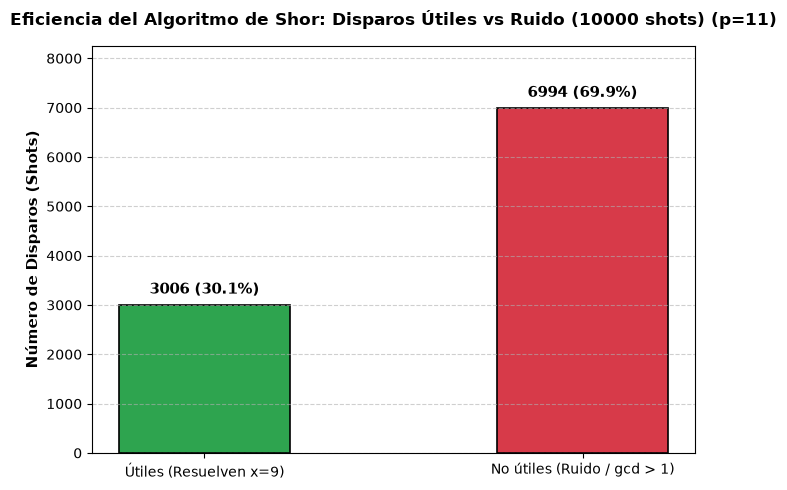

In [ ]:
# 1. Definimos los parámetros

g=2
h=6
p=11 
q=16
l=4

if es_generador(g,p):
    print(f"{g} es generador de Z_{p}^*. Continuando con el resto del circuito...")

# 2. Definimos los registros cuánticos y clásicos
    reg_A = QuantumRegister(l, 'A')
    reg_B = QuantumRegister(l, 'B')
    reg_C = QuantumRegister(l, 'C')

    clreg_A = ClassicalRegister(l, 'medida_c')
    clreg_B = ClassicalRegister(l, 'medida_d')

# 3. Creamos el circuito
    qc=QuantumCircuit(reg_A,reg_B,reg_C,clreg_A,clreg_B)

# 4. Aplicamos puertas Hadamard en los registros A y B
    qc.h(reg_A)
    qc.h(reg_B)
    qc.barrier()

# 5. Aplicamos el oráculo
    aplicar_oraculo_matrices(g, h, p, qc, reg_A, reg_B, reg_C)
    qc.barrier()

# 6. Aplicamos ahora la QFT en los dos primeros registros
    qc.append(QFTGate(num_qubits=l), reg_A)
    qc.append(QFTGate(num_qubits=l), reg_B)
    qc.barrier()

# 7. Procedemos a la medición
    qc.measure(reg_A, clreg_A)
    qc.measure(reg_B, clreg_B)

# 8. Pintamos el circuito completo
    # Dibujamos el circuito usando el motor de Matplotlib ('mpl')
    # Usamos el estilo 'iqp', que es el estándar moderno de IBM
    fig = qc.draw('mpl', style='iqp')

    # Guardamos el dibujo directamente en un archivo  png
    
    fig.savefig('circuito_shor(23).png', bbox_inches='tight',dpi=300)

# 9. Pasamos ya a la simulación 
    num_disparos = 10000  
    print(f"[Simulador] Lanzando {num_disparos} disparos...")

    simulador = AerSimulator()
    qc_est_transpilado = transpile(qc, backend=simulador)

    job = simulador.run(qc_est_transpilado, shots=num_disparos)
    resultados = job.result().get_counts()

    posprocesamiento_shor(resultados, g, h, p, q, 35)

# ==============================================================================
# 11. VISUALIZACIÓN DE HISTOGRAMAS (DECIMAL Y BALANCE ÉXITO/RUIDO)
# ==============================================================================

# 1. Decodificación a formato decimal |d=X,c=Y> y clasificación de utilidad
    resultados_decimal = {}
    conteo_utiles = 0
    conteo_no_utiles = 0

    p_sub_1 = p - 1  # 22
    total_shots = sum(resultados.values())

    for estado_bin, freq in resultados.items():
        d_str, c_str = estado_bin.split(' ')
        c = int(c_str, 2)
        d = int(d_str, 2)
        
        # Formato decimal idéntico a la captura
        label_decimal = f"|d={d},c={c}>"
        resultados_decimal[label_decimal] = freq
        
        # Verificación de utilidad matemática
        c_prima = int((c * p_sub_1 - residuo_centrado(c * p_sub_1, q)) / q) % p_sub_1
        d_prima = round(d * p_sub_1 / q) % p_sub_1
        
        es_util = False
        if math.gcd(c_prima, p_sub_1) == 1:
            c_inv = pow(c_prima, -1, p_sub_1)
            x_cand = (-d_prima * c_inv) % p_sub_1
            if pow(g, x_cand, p) == h:
                es_util = True
                
        if es_util:
            conteo_utiles += freq
        else:
            conteo_no_utiles += freq

    # ------------------------------------------------------------------------------
    # HISTOGRAMA: Balance de Disparos Útiles vs No Útiles
    # ------------------------------------------------------------------------------
    fig2, ax = plt.subplots(figsize=(7, 5))

    categorias = ['Útiles (Resuelven x=9)', 'No útiles (Ruido / gcd > 1)']
    valores = [conteo_utiles, conteo_no_utiles]
    colores = ['#2ea44f', '#d73a49']  # Verde para éxito, Rojo para ruido

    bars = ax.bar(categorias, valores, color=colores, width=0.45, edgecolor='black', linewidth=1.2)

    # Añadir los conteos absolutos y porcentajes encima de cada barra
    for bar in bars:
        yval = bar.get_height()
        porcentaje = (yval / total_shots) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, 
            yval + (total_shots * 0.015), 
            f"{yval} ({porcentaje:.1f}%)", 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            fontweight='bold'
        )

    ax.set_ylabel('Número de Disparos (Shots)', fontsize=11, fontweight='bold')
    ax.set_title(f'Eficiencia del Algoritmo de Shor: Disparos Útiles vs Ruido ({total_shots} shots) (p={p})', fontsize=12, fontweight='bold', pad=15)
    ax.set_ylim(0, max(valores) * 1.18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    fig2.savefig('histograma_shor_utilidad(11).png', dpi=300)
    print(f"\n=== HISTOGRAMA: CLASIFICACIÓN DE UTILIDAD (p={p})===")
    display(fig2)
    plt.close(fig2)


else:
    print(f"{g} NO es generador de Z_{p}^*. Abortando el programa.")
    exit()  # Termina la ejecución del programa

### Buscar $x$ tal que $5^x=9\pmod{23}$

#### Solución $x=10$

5 es generador de Z_23^*. Continuando con el resto del circuito...
[Clásico] Factores calculados para Registro A (base 5): [5, 2, 4, 16, 3]
[Clásico] Factores calculados para Registro B (base 18): [18, 2, 4, 16, 3]
[Simulador] Lanzando 10000 disparos...
ANÁLISIS DIDÁCTICO DE LOS ESTADOS MEDIDOS EN EL HISTOGRAMA
Ecuación a resolver: 5^x ≡ 9 (mod 23) 

Estado medido: |d =  0, c =  0⟩ (Proyección: M =  0, c' =  0)  -->  Frecuencia:  455 veces (  4.5%)
  ├── ¿c' es invertible mod 22?: NO (gcd(0, 22) = 22 > 1)
  └── CÓMPUTO IMPOSIBLE: No existe inverso de 0 modulo 22. Este disparo no sirve.
--------------------------------------------------------------------------------
Estado medido: |d =  0, c = 16⟩ (Proyección: M =  0, c' = 11)  -->  Frecuencia:  447 veces (  4.5%)
  ├── ¿c' es invertible mod 22?: NO (gcd(11, 22) = 11 > 1)
  └── CÓMPUTO IMPOSIBLE: No existe inverso de 11 modulo 22. Este disparo no sirve.
--------------------------------------------------------------------------------
Est

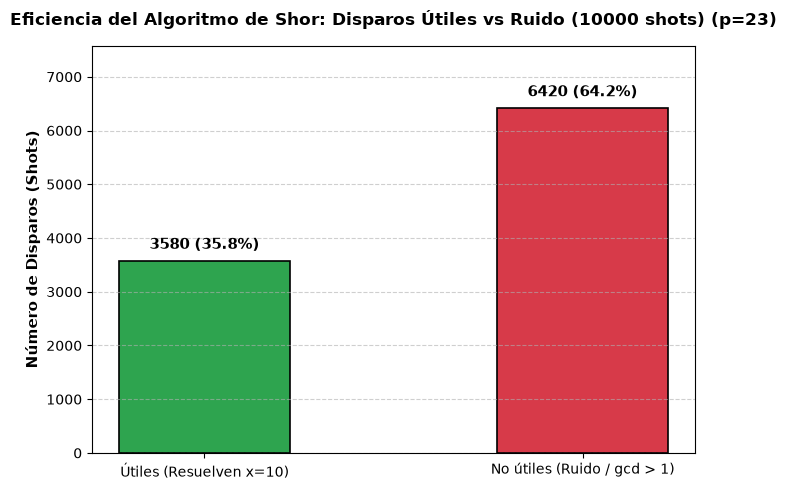

In [ ]:
# 1. Definimos los parámetros

g=5
h=9
p=23 
q=32
l=5

if es_generador(g,p):
    print(f"{g} es generador de Z_{p}^*. Continuando con el resto del circuito...")

# 2. Definimos los registros cuánticos y clásicos
    reg_A = QuantumRegister(l, 'A')
    reg_B = QuantumRegister(l, 'B')
    reg_C = QuantumRegister(l, 'C')

    clreg_A = ClassicalRegister(l, 'medida_c')
    clreg_B = ClassicalRegister(l, 'medida_d')

# 3. Creamos el circuito
    qc=QuantumCircuit(reg_A,reg_B,reg_C,clreg_A,clreg_B)

# 4. Aplicamos puertas Hadamard en los registros A y B
    qc.h(reg_A)
    qc.h(reg_B)
    qc.barrier()

# 5. Aplicamos el oráculo
    aplicar_oraculo_matrices(g, h, p, qc, reg_A, reg_B, reg_C)
    qc.barrier()

# 6. Aplicamos ahora la QFT en los dos primeros registros
    qc.append(QFTGate(num_qubits=l), reg_A)
    qc.append(QFTGate(num_qubits=l), reg_B)
    qc.barrier()

# 7. Procedemos a la medición
    qc.measure(reg_A, clreg_A)
    qc.measure(reg_B, clreg_B)

# 8. Pintamos el circuito completo
    # Dibujamos el circuito usando el motor de Matplotlib ('mpl')
    # Usamos el estilo 'iqp', que es el estándar moderno de IBM 
    fig = qc.draw('mpl', style='iqp')

    # Guardamos el dibujo directamente en un archivo png
    fig.savefig('circuito_shor(23).png', bbox_inches='tight',dpi=300)

# 9. Pasamos ya a la simulación 
    num_disparos = 10000  
    print(f"[Simulador] Lanzando {num_disparos} disparos...")

    simulador = AerSimulator()
    qc_est_transpilado = transpile(qc, backend=simulador)

    job = simulador.run(qc_est_transpilado, shots=num_disparos)
    resultados = job.result().get_counts()

    posprocesamiento_shor(resultados, g, h, p, q, 35)

# ==============================================================================
# 11. VISUALIZACIÓN DE HISTOGRAMAS (DECIMAL Y BALANCE ÉXITO/RUIDO)
# ==============================================================================

# 1. Decodificación a formato decimal |d=X,c=Y> y clasificación de utilidad
    resultados_decimal = {}
    conteo_utiles = 0
    conteo_no_utiles = 0

    p_sub_1 = p - 1  # 22
    total_shots = sum(resultados.values())

    for estado_bin, freq in resultados.items():
        d_str, c_str = estado_bin.split(' ')
        c = int(c_str, 2)
        d = int(d_str, 2)
        
        # Formato decimal idéntico a la captura
        label_decimal = f"|d={d},c={c}>"
        resultados_decimal[label_decimal] = freq
        
        # Verificación de utilidad matemática
        c_prima = int((c * p_sub_1 - residuo_centrado(c * p_sub_1, q)) / q) % p_sub_1
        d_prima = round(d * p_sub_1 / q) % p_sub_1
        
        es_util = False
        if math.gcd(c_prima, p_sub_1) == 1:
            c_inv = pow(c_prima, -1, p_sub_1)
            x_cand = (-d_prima * c_inv) % p_sub_1
            if pow(g, x_cand, p) == h:
                es_util = True
                
        if es_util:
            conteo_utiles += freq
        else:
            conteo_no_utiles += freq

    # ------------------------------------------------------------------------------
    # HISTOGRAMA 2: Balance de Disparos Útiles vs No Útiles
    # ------------------------------------------------------------------------------
    fig2, ax = plt.subplots(figsize=(7, 5))

    categorias = ['Útiles (Resuelven x=10)', 'No útiles (Ruido / gcd > 1)']
    valores = [conteo_utiles, conteo_no_utiles]
    colores = ['#2ea44f', '#d73a49']  # Verde para éxito, Rojo para ruido

    bars = ax.bar(categorias, valores, color=colores, width=0.45, edgecolor='black', linewidth=1.2)

    # Añadir los conteos absolutos y porcentajes encima de cada barra
    for bar in bars:
        yval = bar.get_height()
        porcentaje = (yval / total_shots) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, 
            yval + (total_shots * 0.015), 
            f"{yval} ({porcentaje:.1f}%)", 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            fontweight='bold'
        )

    ax.set_ylabel('Número de Disparos (Shots)', fontsize=11, fontweight='bold')
    ax.set_title(f'Eficiencia del Algoritmo de Shor: Disparos Útiles vs Ruido ({total_shots} shots) (p={p})', fontsize=12, fontweight='bold', pad=15)
    ax.set_ylim(0, max(valores) * 1.18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    fig2.savefig('histograma_shor_utilidad(23).png', dpi=300)
    print(f"\n=== HISTOGRAMA 2: CLASIFICACIÓN DE UTILIDAD (p={p})===")
    display(fig2)
    plt.close(fig2)


else:
    print(f"{g} NO es generador de Z_{p}^*. Abortando el programa.")
    exit()  # Termina la ejecución del programa

### Buscar $x$ tal que $5^x=16\pmod{47}$

#### Solución $x=26$

5 es generador de Z_47^*. Continuando con el resto del circuito...
[Clásico] Factores calculados para Registro A (base 5): [5, 25, 14, 8, 17, 7]
[Clásico] Factores calculados para Registro B (base 3): [3, 9, 34, 28, 32, 37]
[Simulador] Lanzando 10000 disparos...
ANÁLISIS DIDÁCTICO DE LOS ESTADOS MEDIDOS EN EL HISTOGRAMA
Ecuación a resolver: 5^x ≡ 16 (mod 47) 

Estado medido: |d = 53, c = 57⟩ (Proyección: M = 38, c' = 41)  -->  Frecuencia:  232 veces (  2.3%)
  ├── ¿c' es invertible mod 46?: SÍ (Inverso: c'^-1 ≡ 9 mod 46)
  ├── Fórmula: x = -M * c'^-1  -->  x = -38 * 9 ≡ 26 mod 46
  └── ¡ÉXITO! Verificación: 5^26 ≡ 16 mod 47 (¡Da 16!)
--------------------------------------------------------------------------------
Estado medido: |d =  0, c = 32⟩ (Proyección: M =  0, c' = 23)  -->  Frecuencia:  228 veces (  2.3%)
  ├── ¿c' es invertible mod 46?: NO (gcd(23, 46) = 23 > 1)
  └── CÓMPUTO IMPOSIBLE: No existe inverso de 23 modulo 46. Este disparo no sirve.
-----------------------------------

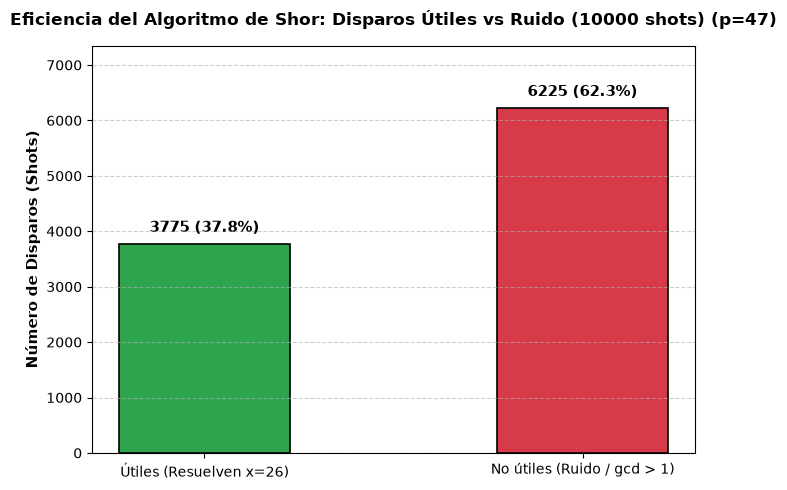

In [ ]:
# 1. Definimos los parámetros

g=5
h=16
p=47 
q=64
l=6

if es_generador(g,p):
    print(f"{g} es generador de Z_{p}^*. Continuando con el resto del circuito...")

# 2. Definimos los registros cuánticos y clásicos
    reg_A = QuantumRegister(l, 'A')
    reg_B = QuantumRegister(l, 'B')
    reg_C = QuantumRegister(l, 'C')

    clreg_A = ClassicalRegister(l, 'medida_c')
    clreg_B = ClassicalRegister(l, 'medida_d')

# 3. Creamos el circuito
    qc=QuantumCircuit(reg_A,reg_B,reg_C,clreg_A,clreg_B)

# 4. Aplicamos puertas Hadamard en los registros A y B
    qc.h(reg_A)
    qc.h(reg_B)
    qc.barrier()

# 5. Aplicamos el oráculo
    aplicar_oraculo_matrices(g, h, p, qc, reg_A, reg_B, reg_C)
    qc.barrier()

# 6. Aplicamos ahora la QFT en los dos primeros registros
    qc.append(QFTGate(num_qubits=l), reg_A)
    qc.append(QFTGate(num_qubits=l), reg_B)
    qc.barrier()

# 7. Procedemos a la medición
    qc.measure(reg_A, clreg_A)
    qc.measure(reg_B, clreg_B)

# 8. Pintamos el circuito completo
    # Dibujamos el circuito usando el motor de Matplotlib ('mpl')
    # Usamos el estilo 'iqp', que es el estándar moderno de IBM 
    fig = qc.draw('mpl', style='iqp')

    # Guardamos el dibujo directamente en un archivo png
    fig.savefig('circuito_shor(23).png', bbox_inches='tight',dpi=300)

# 9. Pasamos ya a la simulación 
    num_disparos = 10000  
    print(f"[Simulador] Lanzando {num_disparos} disparos...")

    simulador = AerSimulator()
    qc_est_transpilado = transpile(qc, backend=simulador)

    job = simulador.run(qc_est_transpilado, shots=num_disparos)
    resultados = job.result().get_counts()

    posprocesamiento_shor(resultados, g, h, p, q, 35)

# ==============================================================================
# 11. VISUALIZACIÓN DE HISTOGRAMAS (DECIMAL Y BALANCE ÉXITO/RUIDO)
# ==============================================================================

# 1. Decodificación a formato decimal |d=X,c=Y> y clasificación de utilidad
    resultados_decimal = {}
    conteo_utiles = 0
    conteo_no_utiles = 0

    p_sub_1 = p - 1  # 22
    total_shots = sum(resultados.values())

    for estado_bin, freq in resultados.items():
        d_str, c_str = estado_bin.split(' ')
        c = int(c_str, 2)
        d = int(d_str, 2)
        
        # Formato decimal idéntico a la captura
        label_decimal = f"|d={d},c={c}>"
        resultados_decimal[label_decimal] = freq
        
        # Verificación de utilidad matemática
        c_prima = int((c * p_sub_1 - residuo_centrado(c * p_sub_1, q)) / q) % p_sub_1
        d_prima = round(d * p_sub_1 / q) % p_sub_1
        
        es_util = False
        if math.gcd(c_prima, p_sub_1) == 1:
            c_inv = pow(c_prima, -1, p_sub_1)
            x_cand = (-d_prima * c_inv) % p_sub_1
            if pow(g, x_cand, p) == h:
                es_util = True
                
        if es_util:
            conteo_utiles += freq
        else:
            conteo_no_utiles += freq

    # ------------------------------------------------------------------------------
    # HISTOGRAMA: Balance de Disparos Útiles vs No Útiles
    # ------------------------------------------------------------------------------
    fig2, ax = plt.subplots(figsize=(7, 5))

    categorias = ['Útiles (Resuelven x=26)', 'No útiles (Ruido / gcd > 1)']
    valores = [conteo_utiles, conteo_no_utiles]
    colores = ['#2ea44f', '#d73a49']  # Verde para éxito, Rojo para ruido

    bars = ax.bar(categorias, valores, color=colores, width=0.45, edgecolor='black', linewidth=1.2)

    # Añadir los conteos absolutos y porcentajes encima de cada barra
    for bar in bars:
        yval = bar.get_height()
        porcentaje = (yval / total_shots) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, 
            yval + (total_shots * 0.015), 
            f"{yval} ({porcentaje:.1f}%)", 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            fontweight='bold'
        )

    ax.set_ylabel('Número de Disparos (Shots)', fontsize=11, fontweight='bold')
    ax.set_title(f'Eficiencia del Algoritmo de Shor: Disparos Útiles vs Ruido ({total_shots} shots) (p={p})', fontsize=12, fontweight='bold', pad=15)
    ax.set_ylim(0, max(valores) * 1.18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    fig2.savefig('histograma_shor_utilidad(47).png', dpi=300)
    print(f"\n=== HISTOGRAMA 2: CLASIFICACIÓN DE UTILIDAD (p={p})===")
    display(fig2)
    plt.close(fig2)


else:
    print(f"{g} NO es generador de Z_{p}^*. Abortando el programa.")
    exit()  # Termina la ejecución del programa

### Buscar $x$ tal que $2^x=10\pmod{59}$

#### Solución $x=7$

2 es generador de Z_59^*. Continuando con el resto del circuito...
[Clásico] Factores calculados para Registro A (base 2): [2, 4, 16, 20, 46, 51]
[Clásico] Factores calculados para Registro B (base 6): [6, 36, 57, 4, 16, 20]
[Simulador] Lanzando 1000 disparos...
ANÁLISIS DIDÁCTICO DE LOS ESTADOS MEDIDOS EN EL HISTOGRAMA
Ecuación a resolver: 2^x ≡ 10 (mod 59) 

Estado medido: |d =  0, c =  0⟩ (Proyección: M =  0, c' =  0)  -->  Frecuencia:   24 veces (  2.4%)
  ├── ¿c' es invertible mod 58?: NO (gcd(0, 58) = 58 > 1)
  └── CÓMPUTO IMPOSIBLE: No existe inverso de 0 modulo 58. Este disparo no sirve.
--------------------------------------------------------------------------------
Estado medido: |d = 51, c = 11⟩ (Proyección: M = 46, c' = 10)  -->  Frecuencia:   22 veces (  2.2%)
  ├── ¿c' es invertible mod 58?: NO (gcd(10, 58) = 2 > 1)
  └── CÓMPUTO IMPOSIBLE: No existe inverso de 10 modulo 58. Este disparo no sirve.
---------------------------------------------------------------------------

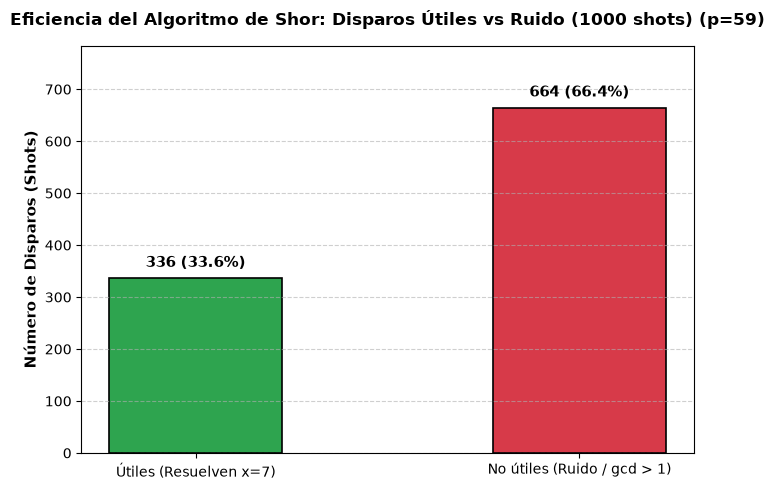

In [ ]:
# 1. Definimos los parámetros

g=2
h=10
p=59 
q=64
l=6

if es_generador(g,p):
    print(f"{g} es generador de Z_{p}^*. Continuando con el resto del circuito...")

# 2. Definimos los registros cuánticos y clásicos
    reg_A = QuantumRegister(l, 'A')
    reg_B = QuantumRegister(l, 'B')
    reg_C = QuantumRegister(l, 'C')

    clreg_A = ClassicalRegister(l, 'medida_c')
    clreg_B = ClassicalRegister(l, 'medida_d')

# 3. Creamos el circuito
    qc=QuantumCircuit(reg_A,reg_B,reg_C,clreg_A,clreg_B)

# 4. Aplicamos puertas Hadamard en los registros A y B
    qc.h(reg_A)
    qc.h(reg_B)
    qc.barrier()

# 5. Aplicamos el oráculo
    aplicar_oraculo_matrices(g, h, p, qc, reg_A, reg_B, reg_C)
    qc.barrier()

# 6. Aplicamos ahora la QFT en los dos primeros registros
    qc.append(QFTGate(num_qubits=l), reg_A)
    qc.append(QFTGate(num_qubits=l), reg_B)
    qc.barrier()

# 7. Procedemos a la medición
    qc.measure(reg_A, clreg_A)
    qc.measure(reg_B, clreg_B)

# 8. Pintamos el circuito completo
    # Dibujamos el circuito usando el motor de Matplotlib ('mpl')
    # Usamos el estilo 'iqp', que es el estándar moderno de IBM
    fig = qc.draw('mpl', style='iqp')

    # Guardamos el dibujo directamente en un archivo png
    fig.savefig('circuito_shor(23).png', bbox_inches='tight',dpi=300)

# 9. Pasamos ya a la simulación 
    num_disparos = 1000  
    print(f"[Simulador] Lanzando {num_disparos} disparos...")

    simulador = AerSimulator()
    qc_est_transpilado = transpile(qc, backend=simulador)

    job = simulador.run(qc_est_transpilado, shots=num_disparos)
    resultados = job.result().get_counts()

    posprocesamiento_shor(resultados, g, h, p, q, 35)

# ==============================================================================
# 11. VISUALIZACIÓN DE HISTOGRAMAS (DECIMAL Y BALANCE ÉXITO/RUIDO)
# ==============================================================================

# 1. Decodificación a formato decimal |d=X,c=Y> y clasificación de utilidad
    resultados_decimal = {}
    conteo_utiles = 0
    conteo_no_utiles = 0

    p_sub_1 = p - 1  # 22
    total_shots = sum(resultados.values())

    for estado_bin, freq in resultados.items():
        d_str, c_str = estado_bin.split(' ')
        c = int(c_str, 2)
        d = int(d_str, 2)
        
        # Formato decimal idéntico a la captura
        label_decimal = f"|d={d},c={c}>"
        resultados_decimal[label_decimal] = freq
        
        # Verificación de utilidad matemática
        c_prima = int((c * p_sub_1 - residuo_centrado(c * p_sub_1, q)) / q) % p_sub_1
        d_prima = round(d * p_sub_1 / q) % p_sub_1
        
        es_util = False
        if math.gcd(c_prima, p_sub_1) == 1:
            c_inv = pow(c_prima, -1, p_sub_1)
            x_cand = (-d_prima * c_inv) % p_sub_1
            if pow(g, x_cand, p) == h:
                es_util = True
                
        if es_util:
            conteo_utiles += freq
        else:
            conteo_no_utiles += freq

    # ------------------------------------------------------------------------------
    # HISTOGRAMA: Balance de Disparos Útiles vs No Útiles
    # ------------------------------------------------------------------------------
    fig2, ax = plt.subplots(figsize=(7, 5))

    categorias = ['Útiles (Resuelven x=7)', 'No útiles (Ruido / gcd > 1)']
    valores = [conteo_utiles, conteo_no_utiles]
    colores = ['#2ea44f', '#d73a49']  # Verde para éxito, Rojo para ruido

    bars = ax.bar(categorias, valores, color=colores, width=0.45, edgecolor='black', linewidth=1.2)

    # Añadir los conteos absolutos y porcentajes encima de cada barra
    for bar in bars:
        yval = bar.get_height()
        porcentaje = (yval / total_shots) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, 
            yval + (total_shots * 0.015), 
            f"{yval} ({porcentaje:.1f}%)", 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            fontweight='bold'
        )

    ax.set_ylabel('Número de Disparos (Shots)', fontsize=11, fontweight='bold')
    ax.set_title(f'Eficiencia del Algoritmo de Shor: Disparos Útiles vs Ruido ({total_shots} shots) (p={p})', fontsize=12, fontweight='bold', pad=15)
    ax.set_ylim(0, max(valores) * 1.18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    fig2.savefig('histograma_shor_utilidad(59).png', dpi=300)
    print(f"\n=== HISTOGRAMA 2: CLASIFICACIÓN DE UTILIDAD (p={p})===")
    display(fig2)
    plt.close(fig2)


else:
    print(f"{g} NO es generador de Z_{p}^*. Abortando el programa.")
    exit()  # Termina la ejecución del programa

### Buscar $x$ tal que $2^x=15\pmod{83}$

#### Solución $x=17$

2 es generador de Z_83^*. Continuando con el resto del circuito...
[Clásico] Factores calculados para Registro A (base 2): [2, 4, 16, 7, 49, 77, 36]
[Clásico] Factores calculados para Registro B (base 72): [72, 38, 33, 10, 17, 40, 23]
[Simulador] Lanzando 1000 disparos...
ANÁLISIS DIDÁCTICO DE LOS ESTADOS MEDIDOS EN EL HISTOGRAMA
Ecuación a resolver: 2^x ≡ 15 (mod 83) 

Estado medido: |d =  0, c =  0⟩ (Proyección: M =  0, c' =  0)  -->  Frecuencia:   18 veces (  1.8%)
  ├── ¿c' es invertible mod 82?: NO (gcd(0, 82) = 82 > 1)
  └── CÓMPUTO IMPOSIBLE: No existe inverso de 0 modulo 82. Este disparo no sirve.
--------------------------------------------------------------------------------
Estado medido: |d = 11, c = 67⟩ (Proyección: M =  7, c' = 43)  -->  Frecuencia:   15 veces (  1.5%)
  ├── ¿c' es invertible mod 82?: SÍ (Inverso: c'^-1 ≡ 21 mod 82)
  ├── Fórmula: x = -M * c'^-1  -->  x = -7 * 21 ≡ 17 mod 82
  └── ¡ÉXITO! Verificación: 2^17 ≡ 15 mod 83 (¡Da 15!)
--------------------------

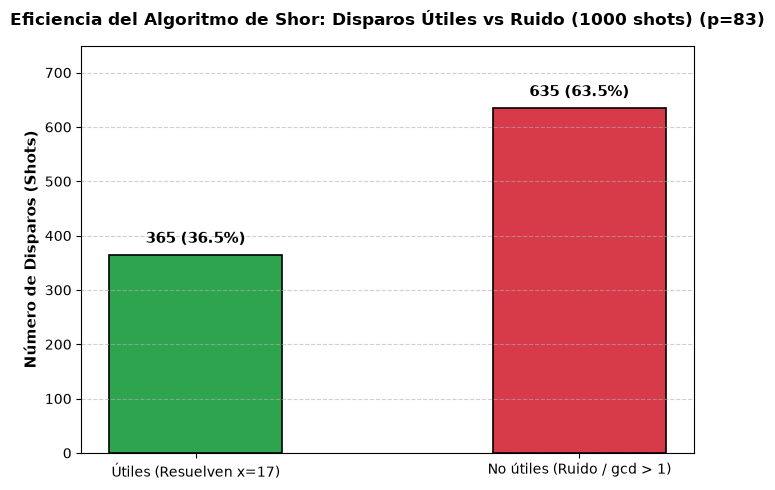

In [ ]:
# 1. Definimos los parámetros

g=2
h=15
p=83 
q=128
l=7

if es_generador(g,p):
    print(f"{g} es generador de Z_{p}^*. Continuando con el resto del circuito...")

# 2. Definimos los registros cuánticos y clásicos
    reg_A = QuantumRegister(l, 'A')
    reg_B = QuantumRegister(l, 'B')
    reg_C = QuantumRegister(l, 'C')

    clreg_A = ClassicalRegister(l, 'medida_c')
    clreg_B = ClassicalRegister(l, 'medida_d')

# 3. Creamos el circuito
    qc=QuantumCircuit(reg_A,reg_B,reg_C,clreg_A,clreg_B)

# 4. Aplicamos puertas Hadamard en los registros A y B
    qc.h(reg_A)
    qc.h(reg_B)
    qc.barrier()

# 5. Aplicamos el oráculo
    aplicar_oraculo_matrices(g, h, p, qc, reg_A, reg_B, reg_C)
    qc.barrier()

# 6. Aplicamos ahora la QFT en los dos primeros registros
    qc.append(QFTGate(num_qubits=l), reg_A)
    qc.append(QFTGate(num_qubits=l), reg_B)
    qc.barrier()

# 7. Procedemos a la medición
    qc.measure(reg_A, clreg_A)
    qc.measure(reg_B, clreg_B)

# 8. Pintamos el circuito completo
    # Dibujamos el circuito usando el motor de Matplotlib ('mpl')
    # Usamos el estilo 'iqp', que es el estándar moderno de IBM
    fig = qc.draw('mpl', style='iqp')

    # Guardamos el dibujo directamente en un archivo png
    fig.savefig('circuito_shor(23).png', bbox_inches='tight',dpi=300)

# 9. Pasamos ya a la simulación 
    num_disparos = 1000  
    print(f"[Simulador] Lanzando {num_disparos} disparos...")

    simulador = AerSimulator()
    qc_est_transpilado = transpile(qc, backend=simulador)

    job = simulador.run(qc_est_transpilado, shots=num_disparos)
    resultados = job.result().get_counts()

    posprocesamiento_shor(resultados, g, h, p, q, 35)

# ==============================================================================
# 11. VISUALIZACIÓN DE HISTOGRAMAS (DECIMAL Y BALANCE ÉXITO/RUIDO)
# ==============================================================================

# 1. Decodificación a formato decimal |d=X,c=Y> y clasificación de utilidad
    resultados_decimal = {}
    conteo_utiles = 0
    conteo_no_utiles = 0

    p_sub_1 = p - 1  # 22
    total_shots = sum(resultados.values())

    for estado_bin, freq in resultados.items():
        d_str, c_str = estado_bin.split(' ')
        c = int(c_str, 2)
        d = int(d_str, 2)
        
        # Formato decimal idéntico a la captura
        label_decimal = f"|d={d},c={c}>"
        resultados_decimal[label_decimal] = freq
        
        # Verificación de utilidad matemática
        c_prima = int((c * p_sub_1 - residuo_centrado(c * p_sub_1, q)) / q) % p_sub_1
        d_prima = round(d * p_sub_1 / q) % p_sub_1
        
        es_util = False
        if math.gcd(c_prima, p_sub_1) == 1:
            c_inv = pow(c_prima, -1, p_sub_1)
            x_cand = (-d_prima * c_inv) % p_sub_1
            if pow(g, x_cand, p) == h:
                es_util = True
                
        if es_util:
            conteo_utiles += freq
        else:
            conteo_no_utiles += freq

    # ------------------------------------------------------------------------------
    # HISTOGRAMA: Balance de Disparos Útiles vs No Útiles
    # ------------------------------------------------------------------------------
    fig2, ax = plt.subplots(figsize=(7, 5))

    categorias = ['Útiles (Resuelven x=17)', 'No útiles (Ruido / gcd > 1)']
    valores = [conteo_utiles, conteo_no_utiles]
    colores = ['#2ea44f', '#d73a49']  # Verde para éxito, Rojo para ruido

    bars = ax.bar(categorias, valores, color=colores, width=0.45, edgecolor='black', linewidth=1.2)

    # Añadir los conteos absolutos y porcentajes encima de cada barra
    for bar in bars:
        yval = bar.get_height()
        porcentaje = (yval / total_shots) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, 
            yval + (total_shots * 0.015), 
            f"{yval} ({porcentaje:.1f}%)", 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            fontweight='bold'
        )

    ax.set_ylabel('Número de Disparos (Shots)', fontsize=11, fontweight='bold')
    ax.set_title(f'Eficiencia del Algoritmo de Shor: Disparos Útiles vs Ruido ({total_shots} shots) (p={p})', fontsize=12, fontweight='bold', pad=15)
    ax.set_ylim(0, max(valores) * 1.18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    fig2.savefig('histograma_shor_utilidad(83).png', dpi=300)
    print(f"\n=== HISTOGRAMA 2: CLASIFICACIÓN DE UTILIDAD (p={p})===")
    display(fig2)
    plt.close(fig2)


else:
    print(f"{g} NO es generador de Z_{p}^*. Abortando el programa.")
    exit()  # Termina la ejecución del programa